In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
# Carga de dataset
df = pd.read_csv("logistic_regression_dataset_v1.0.csv")

df.head()


,hours_study,passed_exam
0,3.75,1
1,9.51,1
2,7.32,1
3,5.99,1
4,1.56,0


In [3]:
# Exploración de dataset
print("Número de registros: ", len(df))
print(df.describe())

Número de registros:  120
       hours_study  passed_exam
count   120.000000   120.000000
mean      4.771167     0.516667
std       2.978341     0.501817
min       0.060000     0.000000
25%       1.982500     0.000000
50%       4.830000     1.000000
75%       7.572500     1.000000
max       9.870000     1.000000


In [4]:
# Distribución de aprobados y reprobados.
df["passed_exam"].value_counts()

,count
passed_exam,
1,62
0,58


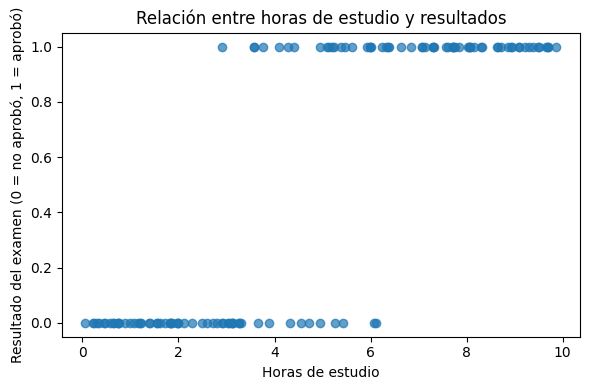

In [5]:
# Visualización de dataset.
plt.figure(figsize=(6,4))

plt.scatter(
    df["hours_study"],
    df["passed_exam"],
    alpha=0.7
)

plt.xlabel("Horas de estudio")
plt.ylabel("Resultado del examen (0 = no aprobó, 1 = aprobó)")
plt.title("Relación entre horas de estudio y resultados")

plt.tight_layout()

plt.savefig("study.png")

plt.show()

In [6]:
# Preparación de features
X = df[["hours_study"]]
y = df["passed_exam"]

In [7]:
# Dividir dataset sobre lo que se va a entrenar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Entrenar modelo
model = LogisticRegression()

model.fit(X_train, y_train)

# Coeficientes del modelo
print("Intercept: ", model.intercept_)
print("Coeficiente: ", model.coef_)

Intercept:  [-5.55448541]
Coeficiente:  [[1.26987842]]


In [9]:
# Evaluar modelo
predictions = model.predict(X_test)

In [10]:
# Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", accuracy)

Accuracy:  0.875


In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
print("Matriz de confusión: \n", cm)

Matriz de confusión: 
 [[10  2]
 [ 1 11]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


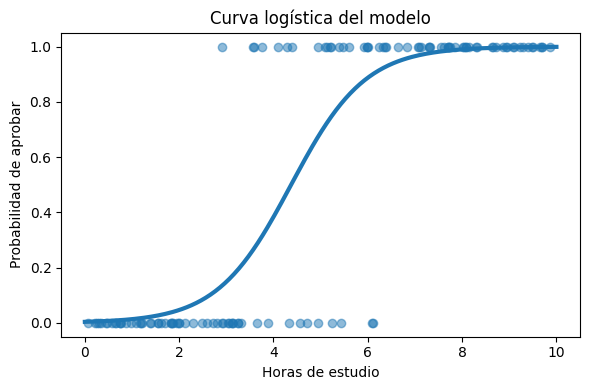

In [12]:
# Visualizar curva de regresión logística
x_range = np.linspace(0, 10, 200).reshape(-1, 1)

probabilities = model.predict_proba(x_range)[:, 1]

plt.figure(figsize=(6, 4))

plt.scatter(
    df["hours_study"],
    df["passed_exam"],
    alpha=0.5
)
plt.plot(x_range, probabilities, linewidth=3)

plt.xlabel("Horas de estudio")
plt.ylabel("Probabilidad de aprobar")

plt.title("Curva logística del modelo")

plt.tight_layout()

plt.savefig("sigmoid-curve.png")

plt.show()


In [20]:
# Probar predicción manualmente
hours = [[5]]

prob = model.predict_proba(hours)[0][1]
print("Probabilidad de aprobar es: ", prob)

"""
Si mi modelo tiene probabilidad de >= 0.65
quiero que se envíen guías de estudio...
"""

Probabilidad de aprobar es:  0.6888839212198397


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'\nSi mi modelo tiene probabilidad de >= 0.65 \nquiero que se envíen guías de estudio...\n'